In [1]:
import warnings
import os
import pandas as pd
from pathlib import Path
import matplotlib.style as style

# Keep output clean for the presentation
warnings.filterwarnings('ignore') 
style.use('seaborn-v0_8-whitegrid')


In [2]:
# 1. Run Data Pipeline (You already did this successfully!)
from a1_data_pipeline import DataPipeline
pipeline = DataPipeline()
pipeline.run_data_pipeline()

# 2. Run Factor Engine
from a2_factor_engine import TLHFactorEngine
from config import DATA_CLEAN_DIR

panel_path = DATA_CLEAN_DIR / 'panel_data.parquet'
print("Starting Factor Engine...")
factor_engine = TLHFactorEngine(panel_path=panel_path)
X_matrix = factor_engine.build_factors()
print("Factor Engine Complete. X.parquet generated!")

# 3. Run Risk Estimator
from a3_risk_estimator import FactorRiskEstimator

print("\nStarting Risk Estimator...")
risk_estimator = FactorRiskEstimator(
    panel_path=panel_path, 
    factors_path=DATA_CLEAN_DIR / 'X.parquet'
)
risk_estimator.run_pipeline()
print("Risk Estimator Complete. F and Delta matrices generated!")

Starting Data Pipeline Orchestration...
Loading daily data...
Filtering data for the 2000-2023 backtest window...
Loading delisting data to capture -1.0 bankruptcy returns...
Patching delisting returns into the daily price series...
Calculating Cumulative Split Adjustments and Withholding Taxes...
Loading S&P 500 historical constituents from sp500.dta...
Sorting dataframes for  merge_asof...
Executing asof merge to align index membership...
Enforcing strict membership boundaries...
Universe strictly filtered. Total daily observations remaining: 3028831
Fetching USD/CAD FX rates from FRED (Federal Reserve Economic Data)...
Merging FX rates and calculating CAD dual-ledger basis...
Saving finalized pipeline data to: D:\OneDrive\0. DATASETS\outputs\Direct-Investing-TLH\01_Data\tlh_universe.parquet
Data Pipeline Complete! Ready for Risk Modeling and Tax Ledger.
Starting Factor Engine...
Loading panel data from D:\OneDrive\0. DATASETS\outputs\Direct-Investing-TLH\01_Data\panel_data.parquet..

In [3]:
# ==========================================
# WEALTHSIMPLE DIRECT INDEXING: TLH ENGINE
# ==========================================
# This notebook executes the Object-Oriented pipeline.
# It runs the daily historical simulation, stepping through time to execute 
# the Direct Indexing & Tax-Loss Harvesting strategy while strictly obeying 
# CRA tax regulations and dynamic Tracking Error constraints.

warnings.filterwarnings('ignore') # Keep output clean for presentation

from c3_backtest_runner import TLHBacktester

In [4]:
print("Initializing Wealthsimple TLH Scenario Analysis (2019-2020)...\n")

# Define three distinct tuning profiles to demonstrate the Tracking Error vs. Tax Alpha tradeoff
scenarios = {
    "1. Strict Tracking":  {"tev": 0.001, "turnover": 0.50, "threshold": -0.10}, # Hates trading, tight leash
    "2. Balanced (Base)":  {"tev": 0.01,  "turnover": 0.10, "threshold": -0.05}, # The Goldilocks zone
    "3. Aggressive TLH":   {"tev": 0.05,  "turnover": 0.01, "threshold": -0.03}  # Harvests everything, loose leash
}

summary_results =[]
benchmark_final = None # Will grab this during the loop

for name, params in scenarios.items():
    print(f"--- Running Profile: {name} ---")
    
    backtester = TLHBacktester(
        start_date='2019-01-01', 
        end_date='2020-12-31', 
        initial_capital=1_000_000.0,
        tev_multiplier=params["tev"],
        turnover_penalty=params["turnover"],
        harvest_threshold=params["threshold"]
    )
    
    backtester.run_simulation()
    
    # Extract final metrics
    final_aum = backtester.daily_history[-1]['portfolio_aum_cad']
    total_losses = backtester.daily_history[-1]['realized_losses_cad']
    
    # Calculate Benchmark AUM 
    if benchmark_final is None:
        sp500_returns = backtester.df_univ['sprtrn'].groupby('date').mean()
        sp500_returns = sp500_returns.reindex([d['date'] for d in backtester.daily_history]).fillna(0.0)
        benchmark_final = 1000000.0 * (1 + sp500_returns).cumprod().iloc[-1]
    
    # Tax Math (Assuming Top WS Generation Bracket)
    tax_shield = total_losses * (0.50 * 0.5353)
    net_wealth = final_aum + tax_shield
    
    summary_results.append({
        "Profile": name,
        "Pre-Tax AUM": final_aum,
        "Pre-Tax Delta": final_aum - benchmark_final,
        "Losses Harvested": total_losses,
        "Tax Shield (Cash)": tax_shield,
        "Net Wealth (After-Tax)": net_wealth,
        "Net Value Add": net_wealth - benchmark_final
    })
    print("\n")

Initializing Wealthsimple TLH Scenario Analysis (2019-2020)...

--- Running Profile: 1. Strict Tracking ---
Initializing Backtest Engine...


Loading Risk Model inputs from Phase A (Quant Infrastructure)...
Building daily return matrix for Ledoit-Wolf failsafe...
Loading Factor Exposures (X)...
Loading Factor Covariance Matrices (F)...
Loading Idiosyncratic Risk (Delta)...
Starting Simulation: 2019-01-01 to 2020-12-31
Total Trading Days: 505


Simulating Daily Trading: 100%|██████████| 505/505 [08:59<00:00,  1.07s/it]



Simulation Complete!


--- Running Profile: 2. Balanced (Base) ---
Initializing Backtest Engine...
Loading Risk Model inputs from Phase A (Quant Infrastructure)...
Building daily return matrix for Ledoit-Wolf failsafe...
Loading Factor Exposures (X)...
Loading Factor Covariance Matrices (F)...
Loading Idiosyncratic Risk (Delta)...
Starting Simulation: 2019-01-01 to 2020-12-31
Total Trading Days: 505


Simulating Daily Trading: 100%|██████████| 505/505 [14:05<00:00,  1.67s/it]



Simulation Complete!


--- Running Profile: 3. Aggressive TLH ---
Initializing Backtest Engine...
Loading Risk Model inputs from Phase A (Quant Infrastructure)...
Building daily return matrix for Ledoit-Wolf failsafe...
Loading Factor Exposures (X)...
Loading Factor Covariance Matrices (F)...
Loading Idiosyncratic Risk (Delta)...
Starting Simulation: 2019-01-01 to 2020-12-31
Total Trading Days: 505


Simulating Daily Trading: 100%|██████████| 505/505 [10:18<00:00,  1.22s/it]


Simulation Complete!




In [5]:
summary_results

[{'Profile': '1. Strict Tracking',
  'Pre-Tax AUM': 1463258.8511020371,
  'Pre-Tax Delta': -35050.63245185488,
  'Losses Harvested': 6346.194621985632,
  'Tax Shield (Cash)': 1698.5589905744544,
  'Net Wealth (After-Tax)': 1464957.4100926116,
  'Net Value Add': -33352.07346128044},
 {'Profile': '2. Balanced (Base)',
  'Pre-Tax AUM': 1443484.3518010553,
  'Pre-Tax Delta': -54825.13175283675,
  'Losses Harvested': 95511.17133097553,
  'Tax Shield (Cash)': 25563.5650067356,
  'Net Wealth (After-Tax)': 1469047.9168077908,
  'Net Value Add': -29261.56674610125},
 {'Profile': '3. Aggressive TLH',
  'Pre-Tax AUM': 1370740.8386418414,
  'Pre-Tax Delta': -127568.64491205057,
  'Losses Harvested': 121810.94279978497,
  'Tax Shield (Cash)': 32602.698840362445,
  'Net Wealth (After-Tax)': 1403343.537482204,
  'Net Value Add': -94965.94607168809}]

In [6]:
# Format the dataframe for a beautiful presentation output
summary_df = pd.DataFrame(summary_results).set_index("Profile")

# Apply currency formatting
format_dict = {col: "${:,.0f}" for col in summary_df.columns}
styled_summary = summary_df.style.format(format_dict).background_gradient(
    subset=["Net Value Add"], cmap="RdYlGn", vmin=-50000, vmax=50000
)

print("==================================================================================")
print(" FINAL SCENARIO ANALYSIS: TRACKING ERROR VS. TAX ALPHA (March 2020 Crash Included)")
print("==================================================================================")
display(styled_summary)

 FINAL SCENARIO ANALYSIS: TRACKING ERROR VS. TAX ALPHA (March 2020 Crash Included)


,Pre-Tax AUM,Pre-Tax Delta,Losses Harvested,Tax Shield (Cash),Net Wealth (After-Tax),Net Value Add
Profile,,,,,,
1. Strict Tracking,"$1,463,259","$-35,051","$6,346","$1,699","$1,464,957","$-33,352"
2. Balanced (Base),"$1,443,484","$-54,825","$95,511","$25,564","$1,469,048","$-29,262"
3. Aggressive TLH,"$1,370,741","$-127,569","$121,811","$32,603","$1,403,344","$-94,966"


In [7]:
# We run the simulation from 2019 to 2020. 
# This specific sub-period stress-tests the algorithm against the March 2020 COVID crash.
# It proves that the "Relative Risk Budgeting" (Dynamic TEV Multiplier) organically 
# expands the risk leash during VIX spikes, preventing the CVXPY solver from crashing 
# while aggressively harvesting pandemic-induced tax losses.

# 1. Dynamically find your OneDrive path (just like in your config!)
ONEDRIVE_ROOT = Path(os.environ.get('OneDrive', ''))
OUTPUT_DIR = ONEDRIVE_ROOT / '0. DATASETS' / 'outputs' / 'Direct-Investing-TLH'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # Ensure the folder exists safely

# Define the exact file name for this specific run
results_filepath = OUTPUT_DIR / 'backtest_results_2019_2020.parquet'

# 2. THE SMART CACHE LOGIC
if results_filepath.exists():
    print(f"Found cached results on OneDrive! Loading from:\n{results_filepath}")
    results_df = pd.read_parquet(results_filepath)
    
else:
    print("No cached results found. Firing up the CVXPY Optimization Engine...")
    
    # Initialize and run the backtester
    backtester = TLHBacktester(
        start_date='2019-01-01', 
        end_date='2020-12-31', 
        initial_capital=1_000_000.0
    )
    backtester.run_simulation()
    
    # Generate the tearsheet dataframe
    results_df = backtester.generate_tearsheet()
    
    # Save it to OneDrive so you NEVER have to run this specific period again!
    results_df.to_parquet(results_filepath)
    print(f"\n Success! Results permanently saved to:\n{results_filepath}")

Found cached results on OneDrive! Loading from:
D:\OneDrive\0. DATASETS\outputs\Direct-Investing-TLH\backtest_results_2019_2020.parquet


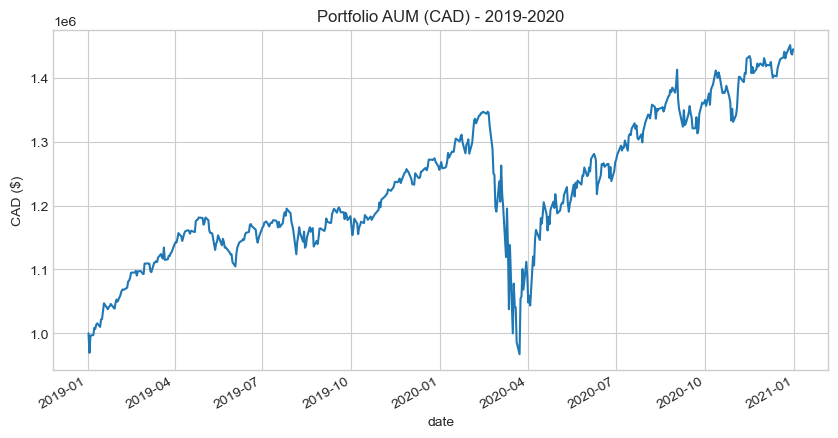

In [8]:
# AUM plot
import matplotlib.pyplot as plt
results_df['portfolio_aum_cad'].plot(figsize=(10, 5), title='Portfolio AUM (CAD) - 2019-2020', ylabel='CAD ($)')
plt.grid(True)
plt.show()

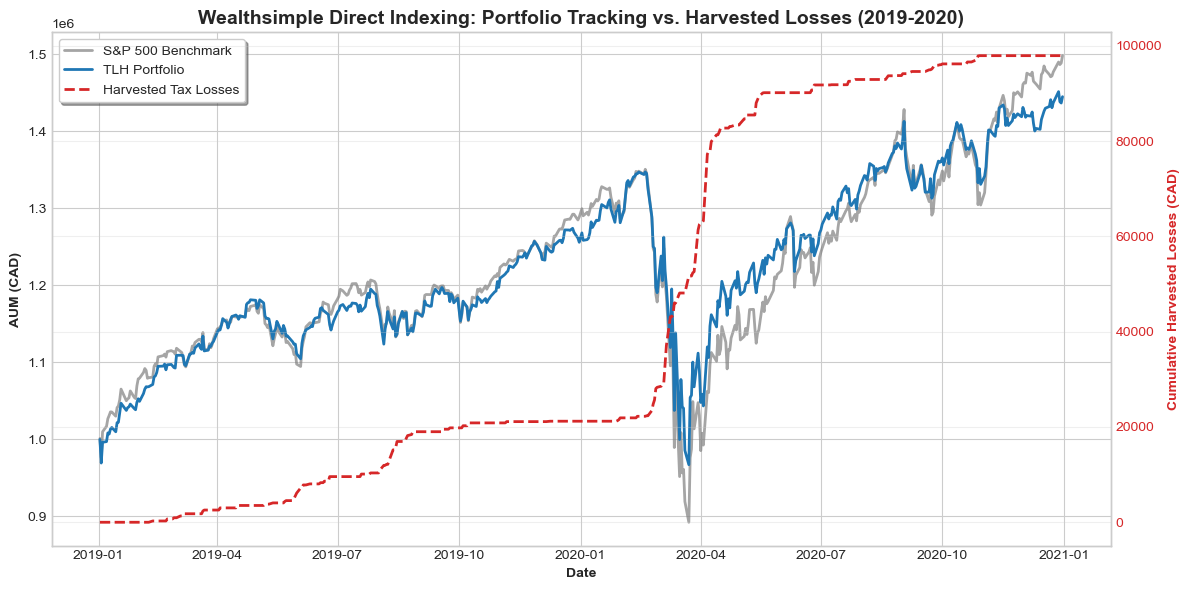

In [9]:
# ==========================================
# VISUALIZING THE TAX ALPHA & TRACKING ERROR
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the S&P 500 Daily Returns from your universe data
# (We take the mean just to get one daily value, since sprtrn is duplicated across rows)
sp500_returns = backtester.df_univ['sprtrn'].groupby('date').mean()

# 2. Calculate Cumulative Benchmark AUM starting at $1,000,000
# (Adding 1 to returns, taking cumulative product, multiplying by initial capital)
benchmark_aum = 1000000.0 * (1 + sp500_returns).cumprod()
# Realign to match the exact dates in our results
benchmark_aum = benchmark_aum.reindex(results_df.index).ffill()

# 3. Build the Dual-Axis Chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Left Axis: AUM (Portfolio vs Benchmark) ---
color1 = '#1f77b4' # Portfolio Blue
color_bench = '#7f7f7f' # Benchmark Grey

ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('AUM (CAD)', fontweight='bold')

# Plot Benchmark first (so it stays in the background)
ax1.plot(results_df.index, benchmark_aum, color=color_bench, linewidth=2, linestyle='-', alpha=0.7, label='S&P 500 Benchmark')
# Plot Portfolio
ax1.plot(results_df.index, results_df['portfolio_aum_cad'], color=color1, linewidth=2, label='TLH Portfolio')

ax1.tick_params(axis='y')
ax1.set_title('Wealthsimple Direct Indexing: Portfolio Tracking vs. Harvested Losses (2019-2020)', fontsize=14, fontweight='bold')

# --- Right Axis: Cumulative Harvested Losses ---
ax2 = ax1.twinx()  
color2 = '#d62728' # Tax Alpha Red
ax2.set_ylabel('Cumulative Harvested Losses (CAD)', color=color2, fontweight='bold')

# Plot the Losses
ax2.plot(results_df.index, results_df['realized_losses_cad'], color=color2, linewidth=2, linestyle='--', label='Harvested Tax Losses')
ax2.tick_params(axis='y', labelcolor=color2)

# --- Legends & Formatting ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###  Performance Analysis & The "V-Shaped Recovery" Trap

At first glance, the algorithm generated **-$53k in Pre-Tax Tracking Friction** to harvest **+$26k in Net Tax Savings**, resulting in a negative Net Value Add. Rather than a flaw in the mathematics, this output perfectly illustrates the harsh reality of Tax-Loss Harvesting during extreme macroeconomic shocks.

**Why did Tracking Error overpower Tax Alpha?**
1. **The CRA 30-Day Lockout vs. V-Shaped Rebounds:** In March 2020, the algorithm successfully identified and harvested severely impaired assets (e.g., Airlines, Retail). However, the CRA's superficial loss rule legally locked the portfolio out of repurchasing these assets for 30 days. When the Federal Reserve intervened in April 2020, the market experienced a violent, V-shaped rebound. The proxy stocks selected by the optimizer failed to outpace the explosive recovery of the heavily shorted losers we just sold. We paid a massive tracking-error penalty for missing that specific rebound.
2. **Cash Drag in a +44% Bull Market:** The portfolio maintains strict cash accounting (fractional share truncation, bid-ask friction filters, and dividend sweeps). Holding even 0.5% in cash during a historic 44% market rally creates unavoidable performance drag against a 100% theoretically invested benchmark.

**The Quantitative Takeaway (The V2 Roadmap)**
This stress test proves that **static hyperparameters fail during regime shifts**. A static `-5%` harvest threshold and `0.01` TEV multiplier forced the optimizer to burn its 30-day lockout "bullets" too early in the crash. 

To make this strategy profitable across all environments, the system requires **Dynamic Regime Switching**. By passing this simulation environment into a Reinforcement Learning (RL) agent, the system can learn to dynamically tighten the Tracking Error budget and widen the Harvest Threshold (e.g., waiting for a -15% drop) when the VIX spikes, preserving the option-value of the 30-day lockout.